# Model Selection, Configuration and Training — REHAB

**Task:** classify each repetition into one of 16 `movement_id` classes. Generate several candidate models/configurations, train them, and compare their performance.

**Builds on:**
- [`Data/README.md`](../Data/README.md) — dataset structure and channel reference.

- [`ETL_Cleaning/`](../ETL_Cleaning/) — cleaning/transformation pipeline that produced `d04_transformed_data` / `manifest.csv`.

- [`EDA_Report/EDA.md`](../EDA_Report/EDA.md) — data quality findings this notebook relies on (class imbalance, padding handling).

This notebook compares three sequence-native model architectures: a two-branch **1D-CNN**, a two-branch **LSTM**, and a two-branch **Transformer encoder**

In [20]:
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sns.set_theme(style="whitegrid", palette="deep")

RANDOM_SEED = 14
torch.manual_seed(RANDOM_SEED)

def find_repo_root(start=None):
    path = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(path, ".git")) and os.path.isdir(os.path.join(path, "utils")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError("Could not locate repo root (.git + utils/) from " + str(start or os.getcwd()))
        path = parent


REPO_ROOT = find_repo_root()
MODEL_SELECTION_DIR = os.path.join(REPO_ROOT, "Model_selection")
for p in (REPO_ROOT, MODEL_SELECTION_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

FIGURES_DIR = os.path.join(MODEL_SELECTION_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

UPPER_COLOR, LOWER_COLOR = sns.color_palette("deep", 2)

print("Repo root:", REPO_ROOT)

Repo root: /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO


In [21]:
from sequence_data import load_sequences, downsample, SequenceDataset
from sequence_models import TwoBranchCNN, TwoBranchLSTM, TwoBranchTransformer, train_and_evaluate

X1, len1, X2, len2, y, movement_id, sample_index = load_sequences()
print(f"Loaded {X1.shape[0]} samples: sensor1 {X1.shape[1:]}  sensor2 {X2.shape[1:]}")
print(f"valid_length_sensor1 range: {len1.min()}-{len1.max()}")
print(f"valid_length_sensor2 range: {len2.min()}-{len2.max()}")

Loaded 3884 samples: sensor1 (880, 6)  sensor2 (880, 6)
valid_length_sensor1 range: 301-880
valid_length_sensor2 range: 5-880


## 1. Identifying the model required

- **Task type:** supervised **multi-class classification**, 16 mutually-exclusive classes (`movement_id` 0–15). Each repetition is one sample.

- Not a regression, ranking, clustering, or per-timestep-labeling problem, we need one class prediction per repetition.

- Not binary: 16 classes rules out plain binary classifiers.

- **Input shape:** each sample is a pair of *variable-length* multi-channel time series (`(880, 6)` per sensor, only the first `valid_length` timesteps real), not a fixed-size feature vector. This is why we look into architectures that natively consume sequences..

## 2. Identifying data types and model compatibility

Each sample is **two independent multi-channel time series**:

| Property | Value | Consequence for model choice |
|---|---|---|
| Shape | `(880, 6)` per sensor per sample (12 channels total) | Rules out any model expecting a fixed-size flat vector. |
| `valid_length_sensor1` | 301–880 | Real signal length varies per sample, padding beyond it is exact zero-fill, never real data |
| `valid_length_sensor2` | 5–880 | Varies independently of sensor1 for the same repetition |
| `n_samples` | 3,884 | Enough for a small CNN/LSTM/Transformer trained from scratch on CPU |
| Class balance | 170–382 samples per class | Favors class-weighted loss over unweighted training |

## 3. Researching candidate models

Given the constraint of variable-length and dual-sensor sequences, the comparison here is between three model families that consume the sequence natively:

| Model | Why included |
|---|---|
| **Two-branch 1D-CNN** | Learns local temporal patterns (short movement sub-phases) via convolution; masked global-average-pooling per branch respects each sensor's own `valid_length` without needing to pad-and-hope; cheap to train on CPU |
| **Two-branch LSTM** | Recurrent state carries information across the *whole* repetition, better suited than convolution to long-range temporal dependencies (e.g. a movement's overall trajectory shape); `pack_padded_sequence` per branch means the recurrence never sees padded zeros as if they were signal |
| **Two-branch Transformer encoder** | Self-attention instead of convolution or recurrence — every timestep can attend directly to every other valid timestep in one step, rather than through a local receptive field (CNN) or a sequential bottleneck (LSTM); a `src_key_padding_mask` derived from `valid_length` keeps padded positions out of the attention entirely (as both keys and the final masked-mean pool) |

**Why not the sklearn tabular family (logistic regression, LDA, KNN, SVM, Random Forest, Histogram Gradient Boosting)** All of them require one fixed-size flat vector per sample. Producing that vector here would mean either hand-engineering summary statistics or flattening to 10,560 raw dimensions against 3,884 samples.

**Two-branch design:** sensor1 (limb IMU, 6 channels) and sensor2 (glove, 6 channels) are not merged into one 12-channel input, because their `valid_length` moves independently a shared time mask over a merged tensor would be wrong for whichever sensor has the shorter valid region. Instead each sensor gets its own branch that pools, packs, or masks according to its own length.

## 4. Configuring and training the models

**Split:** a single **stratified** 80/20 train/test split, computed once and applied identically to all three models.

**Known limitation:** the manifest has no patient identifier, so group-splitting by patient to prevent same-patient repetitions from landing in both train and test isn't possible with the data as provided.

**Hyperparameter selection:** each model gets a small 2-config grid (varying hidden width and learning rate). Each config is trained on a stratified 85/15 subsplit of the training data, with early stopping on validation macro-F1 (patience = 5 epochs, max 30 epochs) this is replacing a full k-fold cv loop would multiply neural-net training cost by the fold count. 
The best config (by validation macro-F1) is then retrained on the full training split for exactly the epoch count that reached its best validation score.

In [22]:
from sklearn.model_selection import train_test_split

STRIDE = 8
X1_ds, len1_ds = downsample(X1, len1, STRIDE)
X2_ds, len2_ds = downsample(X2, len2, STRIDE)
print(f"Downsampled sequence length: {X1_ds.shape[1]} timesteps (stride={STRIDE})")

idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
print(f"train: {len(idx_train)}, test: {len(idx_test)}")

def sl(a, ix):
    return a[ix]

X1_train, len1_train, X2_train, len2_train, y_train = (
    sl(X1_ds, idx_train), sl(len1_ds, idx_train), sl(X2_ds, idx_train), sl(len2_ds, idx_train), sl(y, idx_train)
)
X1_test, len1_test, X2_test, len2_test, y_test = (
    sl(X1_ds, idx_test), sl(len1_ds, idx_test), sl(X2_ds, idx_test), sl(len2_ds, idx_test), sl(y, idx_test)
)

model_results = {}


Downsampled sequence length: 110 timesteps (stride=8)
train: 3107, test: 777


In [23]:
cnn_grid = [
    {"hidden_channels": 32, "lr": 1e-3},
    {"hidden_channels": 64, "lr": 5e-4},
]
cnn_result = train_and_evaluate(
    TwoBranchCNN, cnn_grid,
    X1_train, len1_train, X2_train, len2_train, y_train,
    X1_test, len1_test, X2_test, len2_test, y_test,
    max_epochs=30, patience=5, batch_size=64,
)
print(f"CNN best params={cnn_result['best_params']} lr={cnn_result['best_lr']} "
      f"val f1_macro={cnn_result['val_f1_macro']:.3f}  [{cnn_result['search_time_s']:.1f}s search]")
model_results["CNN"] = cnn_result


  TwoBranchCNN params={'hidden_channels': 32} lr=0.001 -> val f1_macro=0.867 @ epoch 15
  TwoBranchCNN params={'hidden_channels': 64} lr=0.0005 -> val f1_macro=0.911 @ epoch 17
CNN best params={'hidden_channels': 64} lr=0.0005 val f1_macro=0.911  [96.7s search]


In [24]:
lstm_grid = [
    {"hidden_size": 32, "lr": 1e-3},
    {"hidden_size": 64, "lr": 5e-4},
]
lstm_result = train_and_evaluate(
    TwoBranchLSTM, lstm_grid,
    X1_train, len1_train, X2_train, len2_train, y_train,
    X1_test, len1_test, X2_test, len2_test, y_test,
    max_epochs=30, patience=5, batch_size=64,
)
print(f"LSTM best params={lstm_result['best_params']} lr={lstm_result['best_lr']} "
      f"val f1_macro={lstm_result['val_f1_macro']:.3f}  [{lstm_result['search_time_s']:.1f}s search]")
model_results["LSTM"] = lstm_result


  TwoBranchLSTM params={'hidden_size': 32} lr=0.001 -> val f1_macro=0.645 @ epoch 29
  TwoBranchLSTM params={'hidden_size': 64} lr=0.0005 -> val f1_macro=0.632 @ epoch 30
LSTM best params={'hidden_size': 32} lr=0.001 val f1_macro=0.645  [208.2s search]


In [25]:
transformer_grid = [
    {"d_model": 32, "nhead": 4, "num_layers": 2, "dim_feedforward": 64, "max_len": X1_train.shape[1], "lr": 1e-3},
    {"d_model": 64, "nhead": 4, "num_layers": 2, "dim_feedforward": 128, "max_len": X1_train.shape[1], "lr": 5e-4},
]
transformer_result = train_and_evaluate(
    TwoBranchTransformer, transformer_grid,
    X1_train, len1_train, X2_train, len2_train, y_train,
    X1_test, len1_test, X2_test, len2_test, y_test,
    max_epochs=30, patience=5, batch_size=64,
)
model_results["Transformer"] = transformer_result
print(f"Transformer best params={transformer_result['best_params']} lr={transformer_result['best_lr']} "
      f"val f1_macro={transformer_result['val_f1_macro']:.3f}  [{transformer_result['search_time_s']:.1f}s search]")

  TwoBranchTransformer params={'d_model': 32, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 64, 'max_len': 110} lr=0.001 -> val f1_macro=0.859 @ epoch 28
  TwoBranchTransformer params={'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'max_len': 110} lr=0.0005 -> val f1_macro=0.904 @ epoch 27
Transformer best params={'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'max_len': 110} lr=0.0005 val f1_macro=0.904  [261.7s search]


### 4.1 Held-out test set comparison

All three models are now evaluated **once** on the untouched 20% test split.

In [26]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

rows = []
for name, result in model_results.items():
    preds = result["test_preds"]
    rows.append({
        "model": name,
        "test_accuracy": accuracy_score(y_test, preds),
        "test_f1_macro": f1_score(y_test, preds, average="macro"),
        "test_f1_weighted": f1_score(y_test, preds, average="weighted"),
        "val_f1_macro": result["val_f1_macro"],
        "search_time_s": result["search_time_s"],
        "predict_time_s": result["predict_time_s"],
    })

results_df = pd.DataFrame(rows).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
results_path = os.path.join(MODEL_SELECTION_DIR, "model_comparison.csv")
results_df.to_csv(results_path, index=False)
results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,val_f1_macro,search_time_s,predict_time_s
0,Transformer,0.918919,0.915256,0.918880,0.903754,261.743986,0.455673
1,CNN,0.881596,0.882885,0.881799,0.910880,96.720301,0.681463
2,LSTM,0.615187,0.609588,0.607612,0.645102,208.230242,0.163543


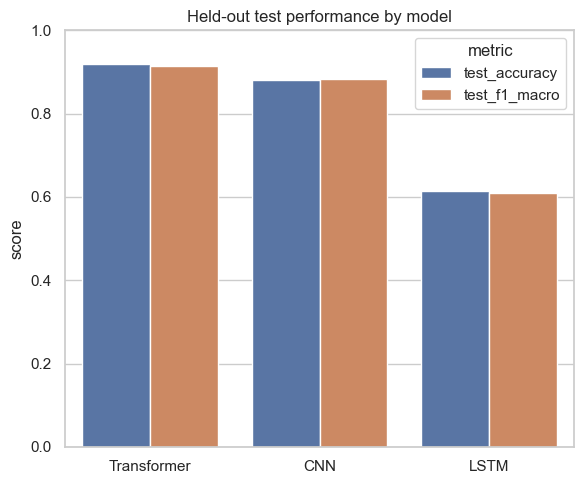

In [27]:
plot_df = results_df.melt(
    id_vars="model", value_vars=["test_accuracy", "test_f1_macro"],
    var_name="metric", value_name="score",
)
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("score")
ax.set_title("Held-out test performance by model")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_model_comparison.png"), dpi=150)
plt.show()

### 4.2 Confusion matrix for the best model

Focuses on where the winning model's errors concentrate.

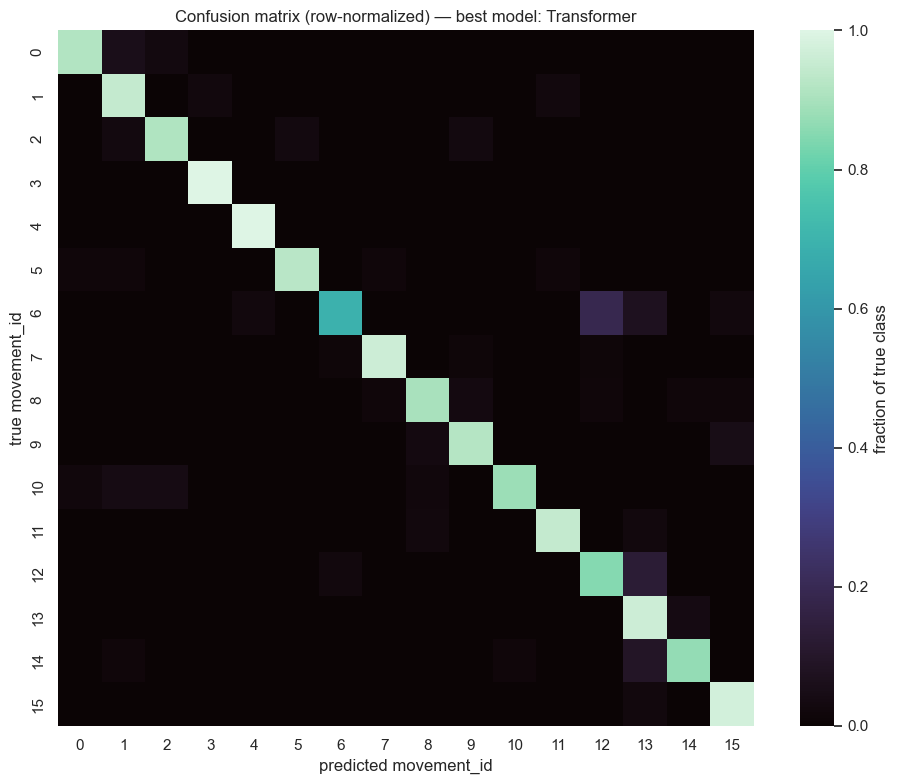

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        36
           1       0.84      0.95      0.89        38
           2       0.91      0.91      0.91        34
           3       0.98      1.00      0.99        40
           4       0.98      1.00      0.99        55
           5       0.98      0.93      0.95        56
           6       0.94      0.69      0.79        42
           7       0.97      0.96      0.97        77
           8       0.93      0.90      0.92        60
           9       0.93      0.92      0.93        61
          10       0.98      0.88      0.93        50
          11       0.95      0.95      0.95        38
          12       0.77      0.85      0.81        40
          13       0.78      0.96      0.86        54
          14       0.94      0.87      0.90        54
          15       0.89      0.98      0.93        42

    accuracy                           0.92       777
   macro avg       0.92   

In [28]:
best_name = results_df.iloc[0]["model"]
best_preds = model_results[best_name]["test_preds"]
classes_sorted = np.sort(np.unique(y))

cm = confusion_matrix(y_test, best_preds, labels=classes_sorted, normalize="true")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="mako", xticklabels=classes_sorted, yticklabels=classes_sorted,
            square=True, cbar_kws={"label": "fraction of true class"}, ax=ax)
ax.set_xlabel("predicted movement_id")
ax.set_ylabel("true movement_id")
ax.set_title(f"Confusion matrix (row-normalized) — best model: {best_name}")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "03_confusion_matrix_best.png"), dpi=150)
plt.show()

print(classification_report(y_test, best_preds, target_names=[str(c) for c in classes_sorted]))

## 5. Report: decisions, results, and recommendation

**Results:**

| Model | Test accuracy | Test macro-F1 | Val macro-F1 (selection) |
|---|---:|---:|---:|
| **Transformer** | **0.919** | **0.915** | 0.904 |
| CNN | 0.882 | 0.883 | 0.911 |
| LSTM | 0.615 | 0.610 | 0.645 |

**Per-class breakdown:** the weakest class is 6 (F1 0.79, recall only 0.69) this is the same class the CNN also struggled with the most (F1 0.74).

**Training:** Both the Transformer's and the LSTM's best configs were still improving when the 30-epoch cap was hit (best epoch 27-28/30 for the Transformer, 29/30 for the LSTM). The CNN's best config, by contrast, plateaued and triggered early stopping normally. This means the reported Transformer/LSTM numbers are a lower bound on what those architectures could reach with a larger epoch number.

**Model-selection decision:** The transformer model the top model by test macro-F1 (0.915). The margin over the CNN (3 points) is real but much narrower than either model's margin over the LSTM (30+ points).

**Notes:**

- **Temporal downsampling (stride 8) was applied for CPU training-time reasons, not modeling reasons** — worth checking whether full-resolution input changes the ranking, since the Transformer's attention cost and the LSTM's recurrence cost are exactly what the downsampling was bought to reduce.

- **This was tested at stride 4** (220 timesteps instead of 110): every model performed worse: Transformer 0.915 → 0.899, CNN 0.883 → 0.824, LSTM 0.610 → 0.385. 
This isn't strong evidence that more temporal detail is not useful, one cause could be that it's a training-budget confound, longer sequences cost more per epoch, so the same fixed `max_epochs=30`/`patience=5` budget gives stride-4 models less effective training than stride-8 models got.

## References

- Lv, M. *et al.* (2026). *A wearable sensor–based kinematic dataset collected
  under standardized rehabilitation tasks from 120 post-stroke patients.*
  Scientific Data 13:1136. https://doi.org/10.1038/s41597-026-07802-2
- [`EDA_Report/EDA.md`](../EDA_Report/EDA.md) — class imbalance findings this
  notebook's §2 references.
- [`Data/README.md`](../Data/README.md) — `manifest.csv` / `valid_length`
  semantics this notebook's `sequence_data.py` relies on.